In [1]:
import numpy as np
import rebound 
sim = rebound.Simulation()

#constants
OMEGA = 0.000182     # [1/s]
one_orbit = 2*np.pi/OMEGA
sim.ri_sei.OMEGA = OMEGA
surface_density = 600    # kg/m^2
sim.G = 6.67428e-11       # N m^2 / kg^2

sim.dt = 1e-3*2.*np.pi/OMEGA # timestep
sim.softening = 0.2       # [m] gravitational softening

# configuring sim box
boxsize = 400.           # [m]
sim.configure_box(boxsize)

sim.N_ghost_x = 2
sim.N_ghost_y = 2

# set up modules 
sim.integrator = "sei"
sim.boundary   = "shear"
sim.gravity    = "tree"
sim.collision  = "tree"
sim.collision_resolve = "hardsphere"

def cor_bridges(r, v):
        eps = 0.32*pow(abs(v)*100.,-0.234)
        if eps>1.:
            eps=1.
        if eps<0.:
            eps=0.
        return eps
sim.coefficient_of_restitution = cor_bridges


# particle initialization function (using power law distribution)
def powerlaw(slope, min_v, max_v):
    y = np.random.uniform()
    pow_max = pow(max_v, slope+1.)
    pow_min = pow(min_v, slope+1.)
    return pow((pow_max-pow_min)*y + pow_min, 1./(slope+1.))

In [2]:
# Constants for densities
density_ice = 917  # kg/m^3 for icy water particles
density_rock = 2150  # kg/m^3 for silicate rock particles

# Define probability for the composition of each particle
prob_ice = 0.95  # 90% chance for icy particles
prob_rock = 0.05  # 10% chance for rocky particles

# Particle Initialization
total_mass = 0.
ice_count = 0
rock_count = 0


while total_mass < surface_density * (boxsize**2):
    # labelling particle type
    if np.random.rand() < prob_ice:
        particle_type = 'ice'
    else:
        particle_type = 'rock'

    # counter
    if particle_type == 'ice':
        ice_count += 1
    else:
        rock_count += 1
    
    # Set density based on particle type
    
    density = density_ice if particle_type == 'ice' else density_rock
    
    # Assign particle radius using a power-law distribution
    radius = powerlaw(slope=-3, min_v=1, max_v=4)  # [m]
    
    # Calculate mass using the selected density
    mass = density * (4/3) * np.pi * (radius**3)
    
    # Initialize particle position and velocity
    x = np.random.uniform(low=-boxsize/2., high=boxsize/2.)
    y = np.random.uniform(low=-boxsize/2., high=boxsize/2.)
    z = np.random.normal()  # small vertical offset

    # Add the particle to the simulation
    

    sim.add(
        m=mass,
        r=radius,
        x=x,
        y=y,
        z=z,
        vx=0.,
        vy=-3./2. * x * OMEGA,
        vz=0.,
        hash = particle_type
    )

    total_mass += mass

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plotParticles(sim, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title(title)
    ax.set_ylabel("Radial Coordinate [m]")
    ax.set_xlabel("Azimuthal Coordinate [m]")
    ax.set_ylim(-boxsize/2., boxsize/2.)
    ax.set_xlim(-boxsize/2., boxsize/2.)

    for p in sim.particles:
        # p.hash outputs a c_long and these are their associated values...
        if p.hash.value == 925511146:
            color = 'dodgerblue'
        elif p.hash.value == 2948346694:
            color = 'red'
        else:
            color = 'grey'

        circ = patches.Circle((p.y, p.x), p.r, facecolor=color, edgecolor='black')
        ax.add_patch(circ)

        

    plt.show()


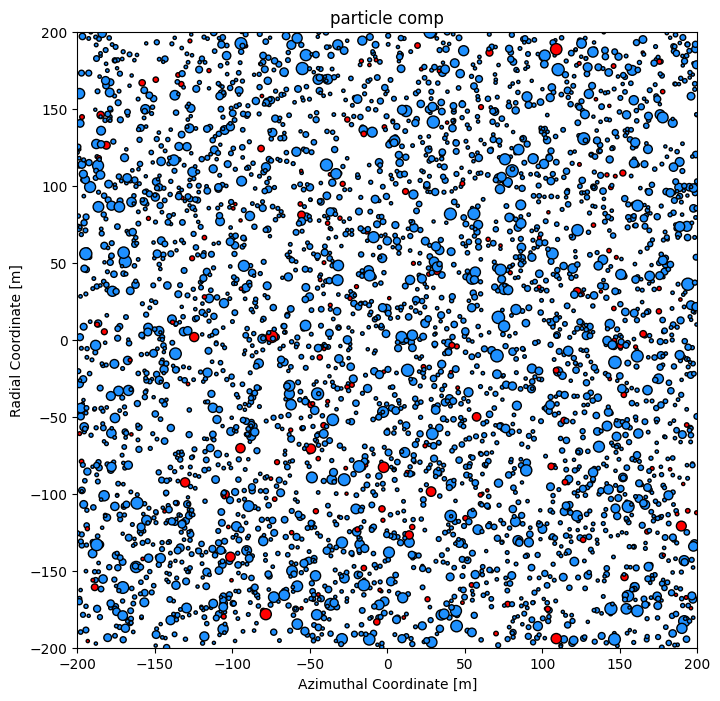

Number of ice particles: 3604
Number of rock particles: 197


In [4]:
plotParticles(sim, 'particle comp')
print(f"Number of ice particles: {ice_count}")
print(f"Number of rock particles: {rock_count}")

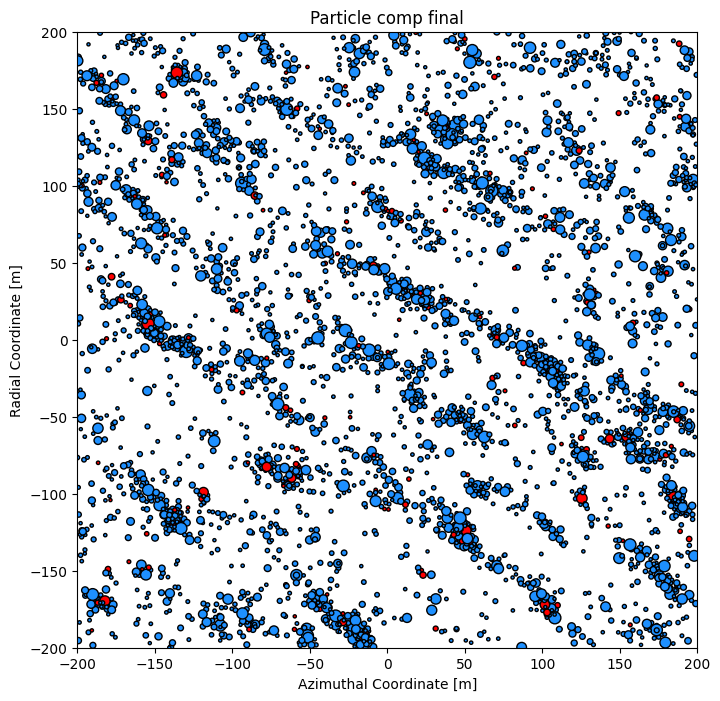

In [5]:
sim.integrate(one_orbit)
plotParticles(sim, 'Particle comp final')